In [1]:
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx

#select particular representative gauge
reg = 'CT'
columnname = str(38)
mask_size = '1658'
list_size = ['892','1658','3454','7071']  
train_size = list_size[1]

#read combined dataframe
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
eve_perf = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_compile_combined.csv')

eve_def = eve_perf['max_absdz']>= 0.1
eve_nodef = eve_perf['max_absdz']< 0.1
rate = eve_perf['mean_prob'].values


In [2]:
def single_exceedance_depth(thresholds, eve_depths, eve_rates): #given threshold of return period as rates, predicts depth
    lambda_exc = np.zeros((len(thresholds))) 
    
    #sort events and rates by depth ascending
    ix = np.argsort(eve_depths)
    eve_depths = eve_depths[ix]
    eve_rates = eve_rates[ix]
    # print(eve_depths)
    
    #calculate cdf from highest to lowest depth, cdf value increases as depth decreases
    eve_cdf = np.cumsum(eve_rates[::-1])[::-1]
    # print(eve_cdf)

    for threshold in range(len(thresholds)):
        # print(threshold,thresholds[threshold])
        
        #check if site is inundated
        if eve_depths.sum() == 0:
            lambda_exc[threshold] = 0
        
        #filter events that exceed threshold of return period    
        exceed_indices = np.where(eve_cdf < thresholds[threshold])[0] #to read array values directly
        # print(exceed_indices,len(exceed_indices))
        if len(exceed_indices) == 0:
            lambda_exc[threshold] = 0
        else:
            lambda_exc[threshold] = eve_depths[exceed_indices[0]] #index to get the depth
    return lambda_exc #give the depth of exceedance for each thresholf retrun period

def single_exceedance_rate(thresholds, eve_depths, eve_rates): #given threshold of depth, predicts rate
    # Annual Mean Rate of threshold exceedance
    lambda_exc = np.zeros(len(thresholds))
    for threshold in range(len(thresholds)):
        ix = np.array(np.where(eve_depths > thresholds[threshold])).squeeze() #events where depth exceeds threshold
        if ix is None:
            lambda_exc[threshold] = 0 #no events exceed threshold
        else:
            lambda_exc[threshold] = eve_rates[ix].sum(axis=0) #sum of rates of events that exceed threshold
    return lambda_exc #give the rate of exceedance for each threshold

Haz Curve for all events

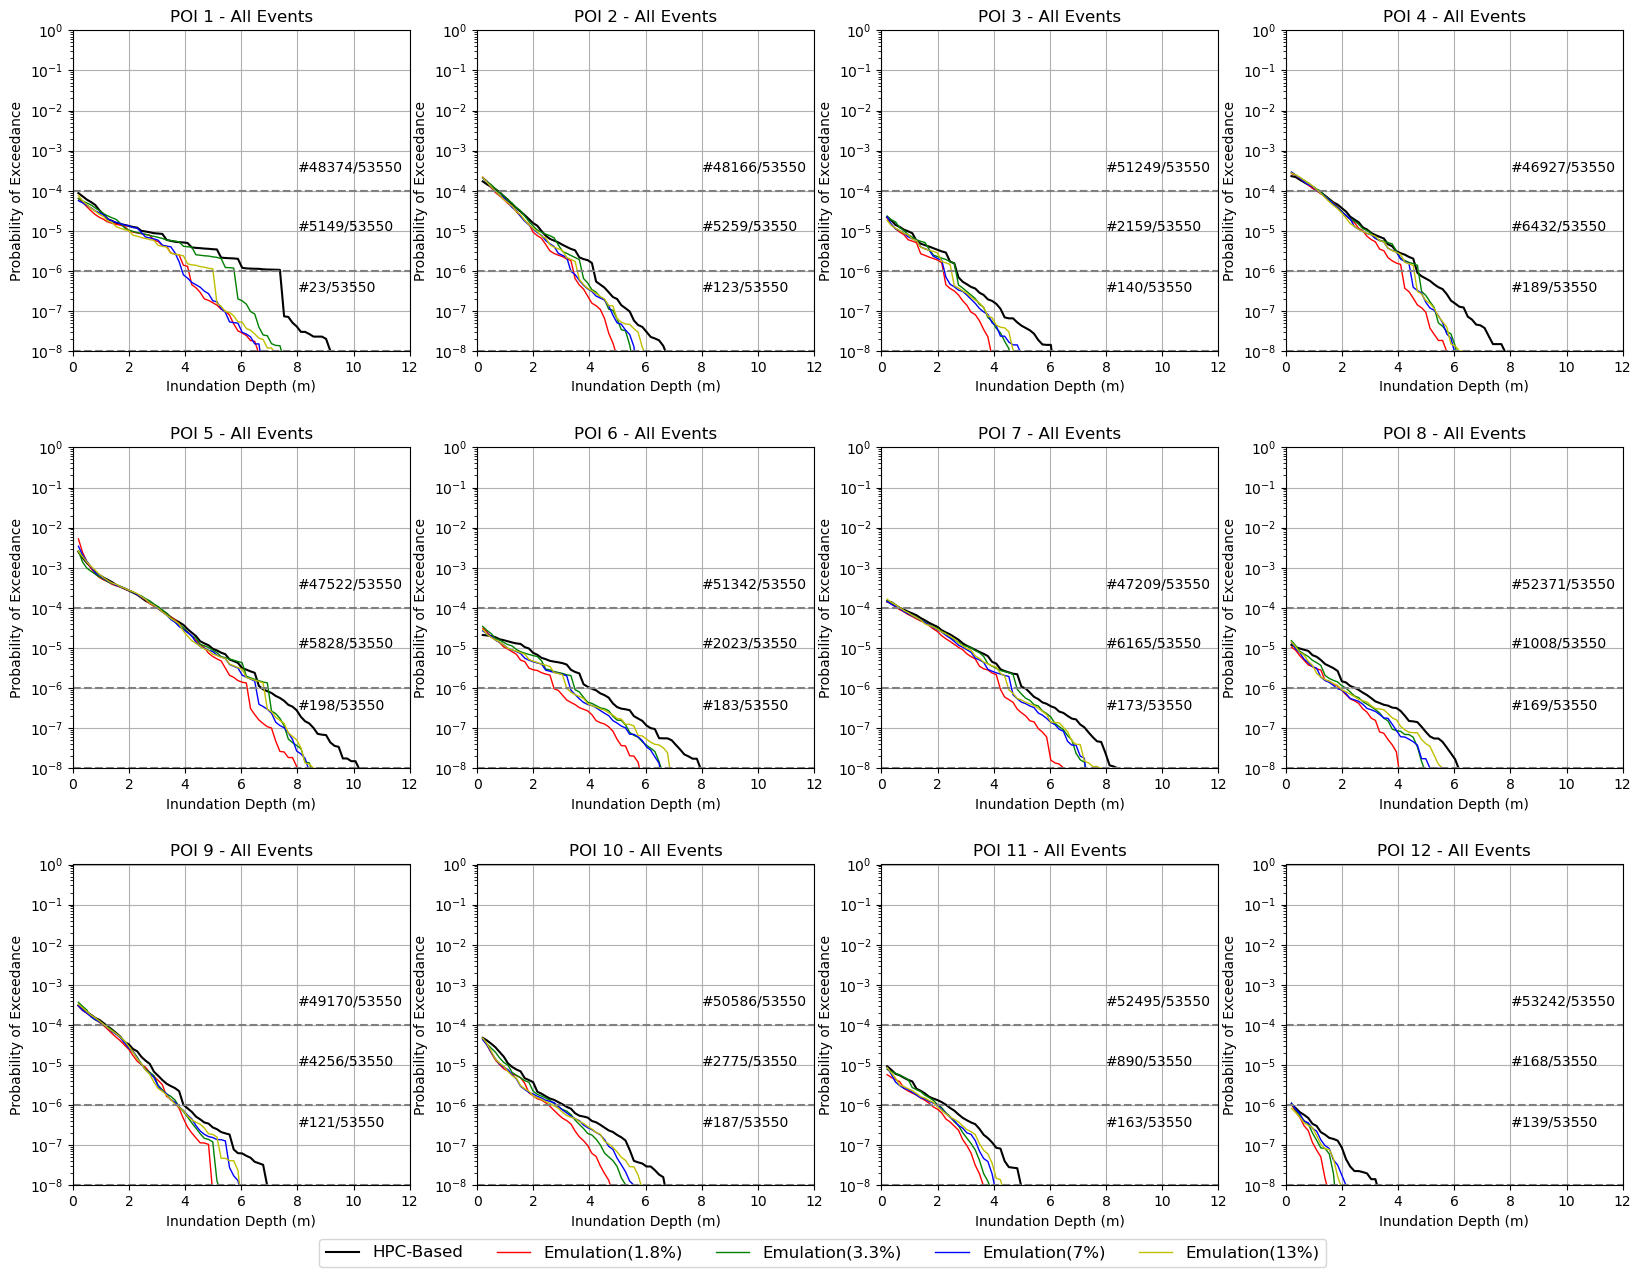

In [38]:
eve_dep_0 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_combined.csv')
eve_dep_1 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[1]}_true_pred_er_combined.csv')
eve_dep_2 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[2]}_true_pred_er_combined.csv')
eve_dep_3 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[3]}_true_pred_er_combined.csv')

#set depth thresholds
# thresholds_depth = [0.2,0.5,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
thresholds_depth = np.linspace(0.2, 15, num=100)
t = [1e-4,1e-6,1e-8]

def exceedance_count(true, thresholds_depth, lambda_exc_true, t = [1e-4,1e-6,1e-8]):
    ncount = []
    for i in range(len(t)):
        depth_idx = np.where(lambda_exc_true < t[i])[0] #get index of depths that exceed threshold probability
        n = true[true > thresholds_depth[depth_idx[0]]].shape[0] #get number of events that exceed threshold depth and set probability
        ncount.append(n)
    ncount[1] = ncount[1] - ncount[2]
    return ncount

# Initialize a figure with 12 subplots (3 rows, 4 columns)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.subplots_adjust(hspace=0.3, wspace=0.2)  # Adjust space between subplots

# Iterate over points
for idx, select_pt in enumerate(range(1, 13)):  # Loop through POIs 1 to 12
    select_pt = str(select_pt)
    
    # True and predicted values
    true = eve_dep_0['T' + select_pt].values
    pred_0 = eve_dep_0['P' + select_pt].values
    pred_1 = eve_dep_1['P' + select_pt].values
    pred_2 = eve_dep_2['P' + select_pt].values
    pred_3 = eve_dep_3['P' + select_pt].values

    # Compute exceedance curves
    lambda_exc_true = single_exceedance_rate(thresholds_depth, true, rate)
    lambda_exc_pred_0 = single_exceedance_rate(thresholds_depth, pred_0, rate)
    lambda_exc_pred_1 = single_exceedance_rate(thresholds_depth, pred_1, rate)
    lambda_exc_pred_2 = single_exceedance_rate(thresholds_depth, pred_2, rate)
    lambda_exc_pred_3 = single_exceedance_rate(thresholds_depth, pred_3, rate)

    # Get subplot position
    row, col = divmod(idx, 4)
    ax = axes[row, col]
    
    # Plot exceedance curves
    ax.plot(thresholds_depth, lambda_exc_true, label='HPC-Based', color='k', linewidth=1.5)
    ax.plot(thresholds_depth, lambda_exc_pred_0, label='Emulation(1.8%)', color='r', linewidth=1)
    ax.plot(thresholds_depth, lambda_exc_pred_1, label='Emulation(3.3%)', color='g', linewidth=1)
    ax.plot(thresholds_depth, lambda_exc_pred_2, label='Emulation(7%)', color='b', linewidth=1)
    ax.plot(thresholds_depth, lambda_exc_pred_3, label='Emulation(13%)', color='y', linewidth=1)
    
    # Add horizontal lines for threshold probabilities
    for thresh in t:
        ax.axhline(y=thresh, color='grey', linestyle='--')
    
    # Add number of events exceeding thresholds
    ncount = exceedance_count(true, thresholds_depth, lambda_exc_true, t)
    ax.text(8, 3 * (1e-4), f'#{eve_dep_0.shape[0] - sum(ncount)}/{eve_dep_0.shape[0]}', color='k')
    ax.text(8, 1e-5, f'#{ncount[0]}/{eve_dep_0.shape[0]}', color='k')
    ax.text(8, 3 * (1e-7), f'#{ncount[1]}/{eve_dep_0.shape[0]}', color='k')
    
    # Set subplot title and axis labels
    ax.set_title(f'POI {select_pt} - All Events')
    ax.set_xlabel('Inundation Depth (m)')
    ax.set_ylabel('Probability of Exceedance')
    ax.set_yscale('log')
    ax.grid(True)
    ax.set_xlim(0, 12)
    ax.set_ylim(1e-8, 1)
    
# Adjust the legend position
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center',  # Position the legend below the subplots
    ncol=5,              # Number of columns in the legend
    fontsize=12,
    bbox_to_anchor=(0.5, 0.05),  # Move legend closer to the subplots
)

# Save and display the figure
plt.savefig(f'{MLDir}/risk/plots/hazard_compare/exceedance_all_sites.png')
plt.show()


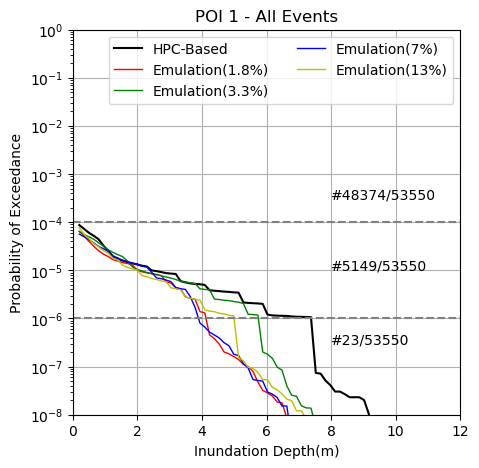

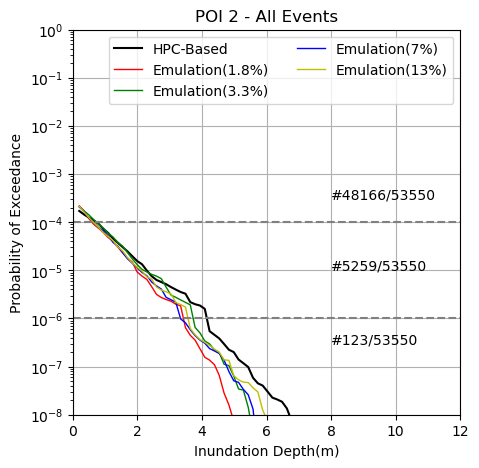

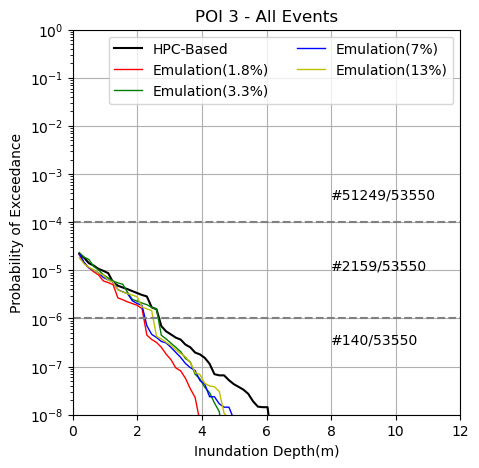

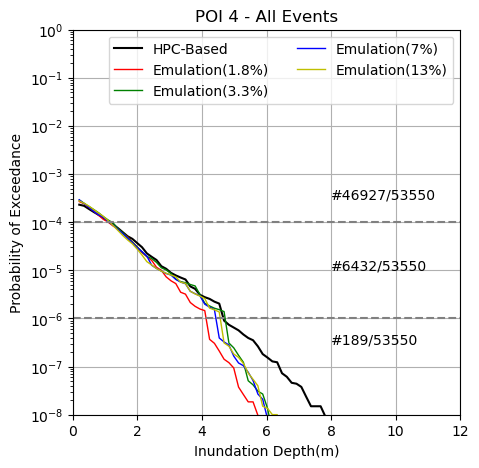

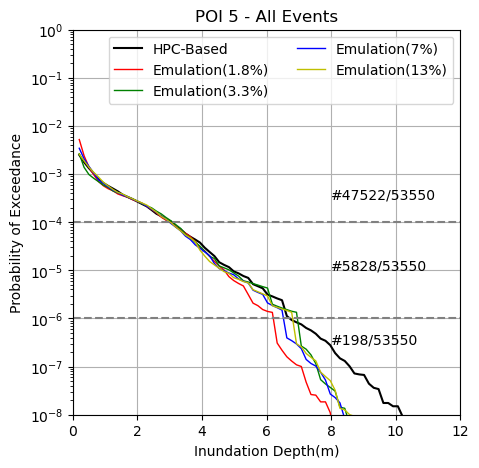

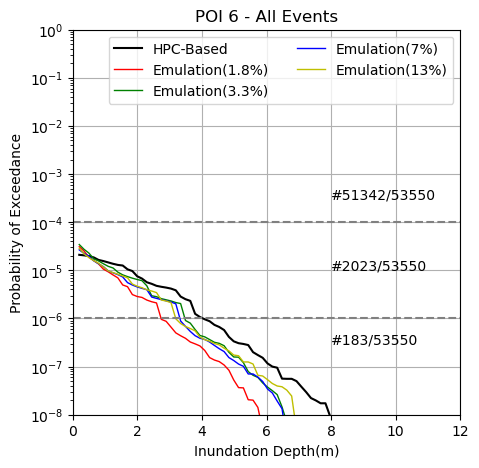

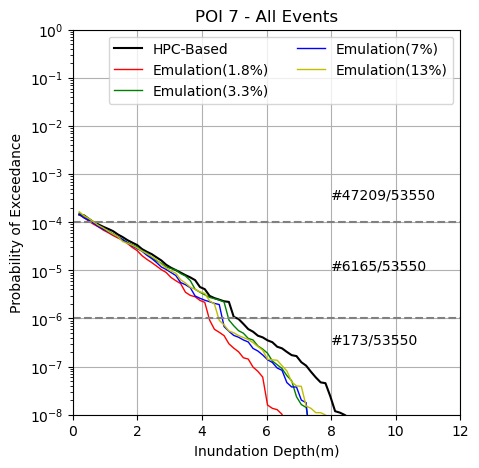

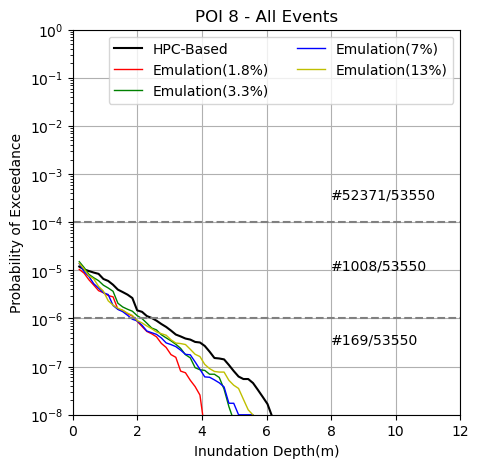

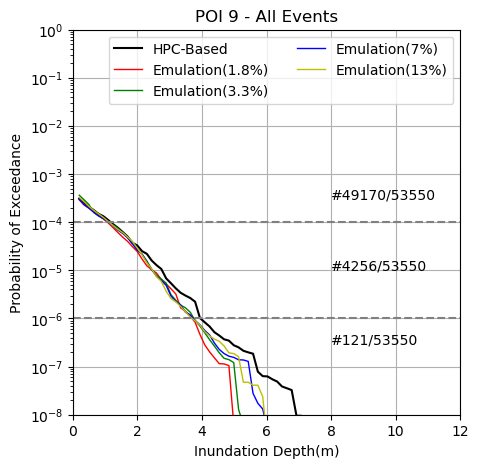

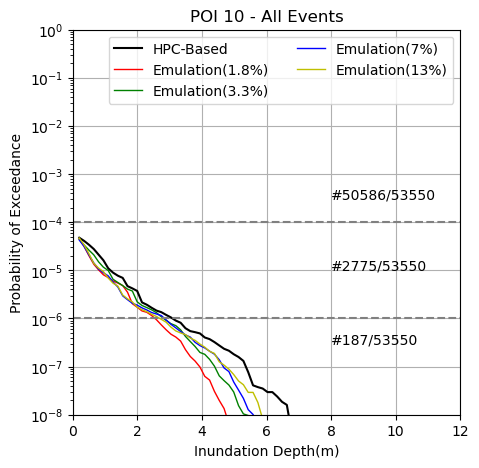

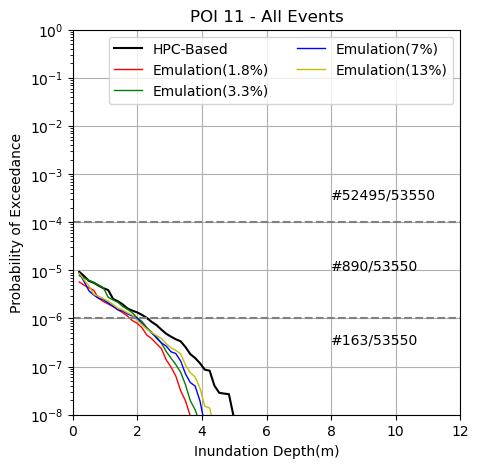

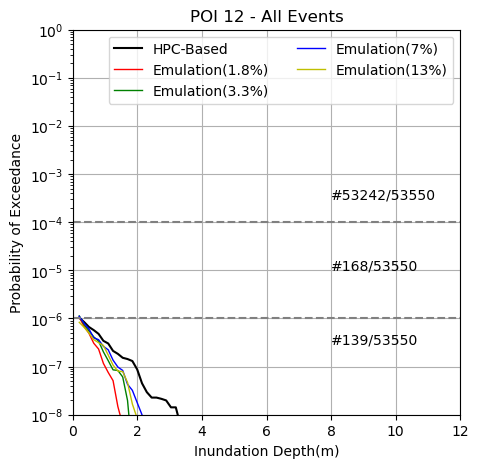

In [3]:
eve_dep_0 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_combined.csv')
eve_dep_1 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[1]}_true_pred_er_combined.csv')
eve_dep_2 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[2]}_true_pred_er_combined.csv')
eve_dep_3 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[3]}_true_pred_er_combined.csv')

#set depth thresholds
# thresholds_depth = [0.2,0.5,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
thresholds_depth = np.linspace(0.2, 15, num=100)
t = [1e-4,1e-6,1e-8]

def exceedance_count(true, thresholds_depth, lambda_exc_true, t = [1e-4,1e-6,1e-8]):
    ncount = []
    for i in range(len(t)):
        depth_idx = np.where(lambda_exc_true < t[i])[0] #get index of depths that exceed threshold probability
        n = true[true > thresholds_depth[depth_idx[0]]].shape[0] #get number of events that exceed threshold depth and set probability
        ncount.append(n)
    ncount[1] = ncount[1] - ncount[2]
    return ncount

#iterate over points
for select_pt in range(1, 13):
    select_pt = str(select_pt)
    #true and predicted values
    true = eve_dep_0['T'+select_pt].values
    pred_0 = eve_dep_0['P'+select_pt].values
    pred_1 = eve_dep_1['P'+select_pt].values
    pred_2 = eve_dep_2['P'+select_pt].values
    pred_3 = eve_dep_3['P'+select_pt].values

    #compute exceedance curve for true
    lambda_exc_true = single_exceedance_rate(thresholds_depth, true, rate)
    lambda_exc_pred_0 = single_exceedance_rate(thresholds_depth, pred_0, rate)
    lambda_exc_pred_1 = single_exceedance_rate(thresholds_depth, pred_1, rate)
    lambda_exc_pred_2 = single_exceedance_rate(thresholds_depth, pred_2, rate)
    lambda_exc_pred_3 = single_exceedance_rate(thresholds_depth, pred_3, rate)

    #plot exceedance curve
    plt.figure(figsize=(5, 5))
    plt.plot(thresholds_depth,lambda_exc_true, label='HPC-Based', color='k',linewidth=1.5)
    plt.plot(thresholds_depth,lambda_exc_pred_0, label='Emulation(1.8%)', color='r',linewidth=1)
    plt.plot(thresholds_depth,lambda_exc_pred_1, label='Emulation(3.3%)', color='g',linewidth=1)
    plt.plot(thresholds_depth,lambda_exc_pred_2, label='Emulation(7%)', color='b',linewidth=1)
    plt.plot(thresholds_depth,lambda_exc_pred_3, label='Emulation(13%)', color='y',linewidth=1)
    #draw line exceed threshold probability of 1e-4, 1e-6, 1e-8
    plt.axhline(y=t[0], color='grey', linestyle='--')
    plt.axhline(y=t[1], color='grey', linestyle='--')
    
    #get nevents exceeding threshold probability of 1e-4, 1e-6, 1e-8 depths
    ncount = exceedance_count(true, thresholds_depth, lambda_exc_true,t)
    plt.text(8, 3*(1e-4), '#'+str(eve_dep_0.shape[0]-sum(ncount))+'/'+str(eve_dep_0.shape[0]), color='k')
    plt.text(8, (1e-5), '#'+str(ncount[0])+'/'+str(eve_dep_0.shape[0]), color='k')
    plt.text(8, 3*(1e-7), '#'+str(ncount[1])+'/'+str(eve_dep_0.shape[0]), color='k')

    plt.xlabel('Inundation Depth(m)')
    plt.ylabel('Probability of Exceedance')
    plt.yscale('log')
    plt.grid(True)
    plt.ylim(1e-8, 1)
    plt.xlim(0, 12)
    plt.legend(ncol=2)
    plt.title(f'POI {select_pt} - All Events')
    plt.savefig(f'{MLDir}/risk/plots/hazard_compare/exceedance_{select_pt}_all.png')
    plt.show()


haz Curve for deformation events

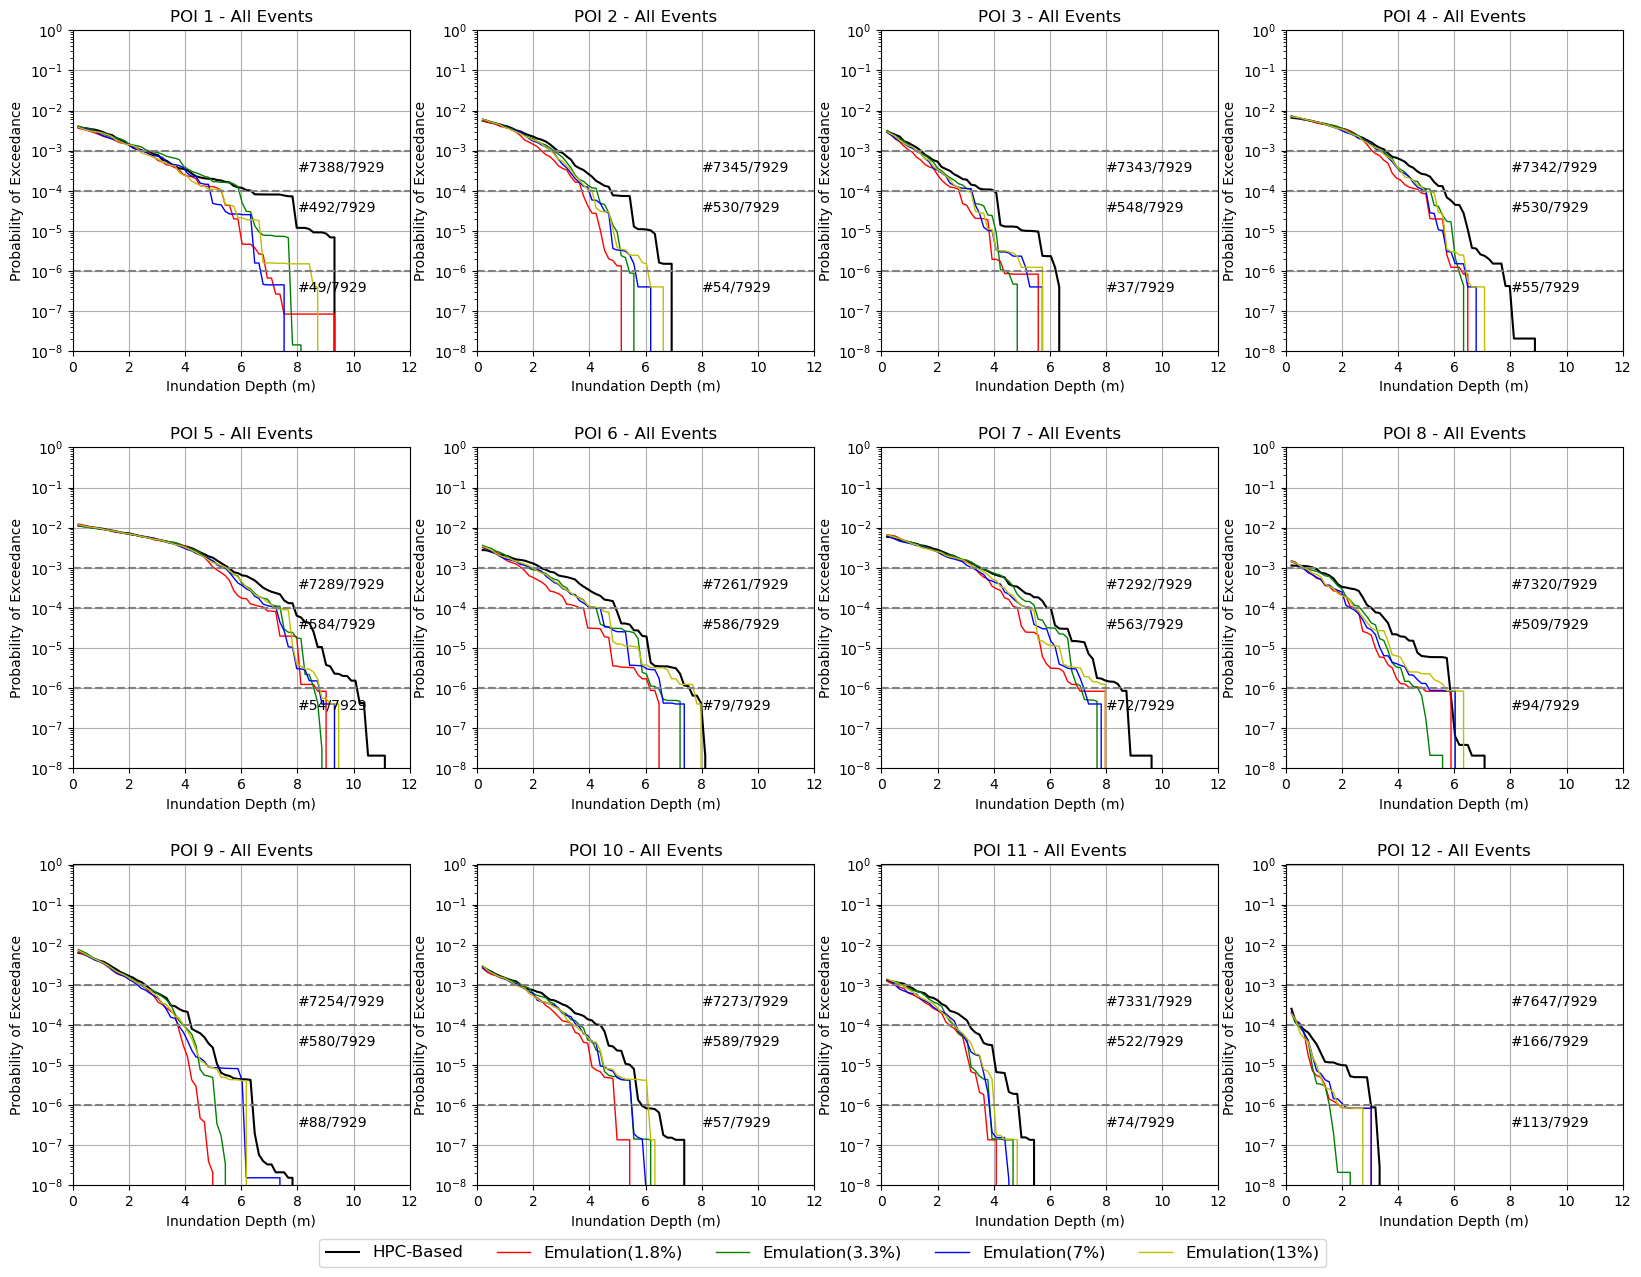

In [44]:
eve_dep_0 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_combined.csv')
eve_dep_1 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[1]}_true_pred_er_combined.csv')
eve_dep_2 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[2]}_true_pred_er_combined.csv')
eve_dep_3 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[3]}_true_pred_er_combined.csv')

eve_dep_0 = eve_dep_0[eve_def]
eve_dep_1 = eve_dep_1[eve_def]
eve_dep_2 = eve_dep_2[eve_def]
eve_dep_3 = eve_dep_3[eve_def]

#set depth thresholds
# thresholds_depth = [0.2,0.5,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
thresholds_depth = np.linspace(0.2, 15, num=100)
t= [1e-3,1e-4,1e-6]

def exceedance_count(true, thresholds_depth, lambda_exc_true, t = [1e-4,1e-6,1e-8]):
    ncount = []
    for i in range(len(t)):
        depth_idx = np.where(lambda_exc_true < t[i])[0]
        n = true[true > thresholds_depth[depth_idx[0]]].shape[0]
        ncount.append(n)
    ncount[1] = ncount[1] - ncount[2]
    return ncount

# Create subplots for all 12 sites
# Initialize a figure with 12 subplots (3 rows, 4 columns)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.subplots_adjust(hspace=0.3, wspace=0.2)  # Adjust space between subplots

# Iterate over points
for idx, select_pt in enumerate(range(1, 13)):  # Loop through POIs 1 to 12
    select_pt = str(select_pt)

    # True and predicted values
    true = eve_dep_0['T'+select_pt].values
    pred_0 = eve_dep_0['P'+select_pt].values
    pred_1 = eve_dep_1['P'+select_pt].values
    pred_2 = eve_dep_2['P'+select_pt].values
    pred_3 = eve_dep_3['P'+select_pt].values

    # Compute exceedance curves
    lambda_exc_true = single_exceedance_rate(thresholds_depth, true, rate)
    lambda_exc_pred_0 = single_exceedance_rate(thresholds_depth, pred_0, rate)
    lambda_exc_pred_1 = single_exceedance_rate(thresholds_depth, pred_1, rate)
    lambda_exc_pred_2 = single_exceedance_rate(thresholds_depth, pred_2, rate)
    lambda_exc_pred_3 = single_exceedance_rate(thresholds_depth, pred_3, rate)

    # Get subplot position
    row, col = divmod(idx, 4)
    ax = axes[row, col]

    # Plot exceedance curves
    ax.plot(thresholds_depth, lambda_exc_true, label='HPC-Based', color='k', linewidth=1.5)
    ax.plot(thresholds_depth, lambda_exc_pred_0, label='Emulation(1.8%)', color='r', linewidth=1)
    ax.plot(thresholds_depth, lambda_exc_pred_1, label='Emulation(3.3%)', color='g', linewidth=1)
    ax.plot(thresholds_depth, lambda_exc_pred_2, label='Emulation(7%)', color='b', linewidth=1)
    ax.plot(thresholds_depth, lambda_exc_pred_3, label='Emulation(13%)', color='y', linewidth=1)

    # Add horizontal lines for threshold probabilities
    for thresh in t:
        ax.axhline(y=thresh, color='grey', linestyle='--')

    # Add exceedance count annotations
    ncount = exceedance_count(true, thresholds_depth, lambda_exc_true, t)
    ax.text(8, 3*(1e-4), '#'+str(eve_dep_0.shape[0]-sum(ncount))+'/'+str(eve_dep_0.shape[0]), color='k')
    ax.text(8, 3*(1e-5), '#'+str(ncount[0])+'/'+str(eve_dep_0.shape[0]), color='k')
    ax.text(8, 3*(1e-7), '#'+str(ncount[1])+'/'+str(eve_dep_0.shape[0]), color='k')

    # Set subplot title and axis labels
    ax.set_title(f'POI {select_pt} - All Events')
    ax.set_xlabel('Inundation Depth (m)')
    ax.set_ylabel('Probability of Exceedance')
    ax.set_yscale('log')
    ax.grid(True)
    ax.set_xlim(0, 12)
    ax.set_ylim(1e-8, 1)

# Adjust the legend position
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center',  # Position the legend below the subplots
    ncol=5,              # Number of columns in the legend
    fontsize=12,
    bbox_to_anchor=(0.5, 0.05),  # Move legend closer to the subplots
)

# Adjust layout and save
plt.savefig(f'{MLDir}/risk/plots/hazard_compare/exceedance_all_def.png')
plt.show()


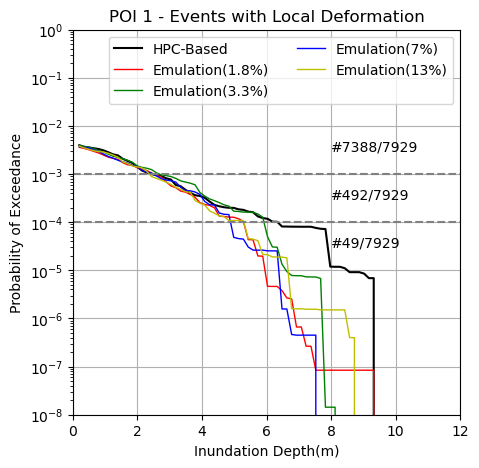

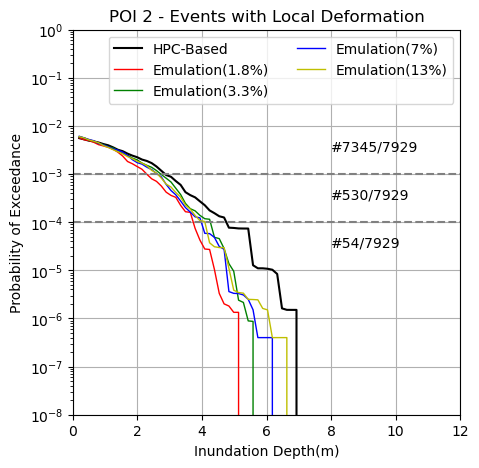

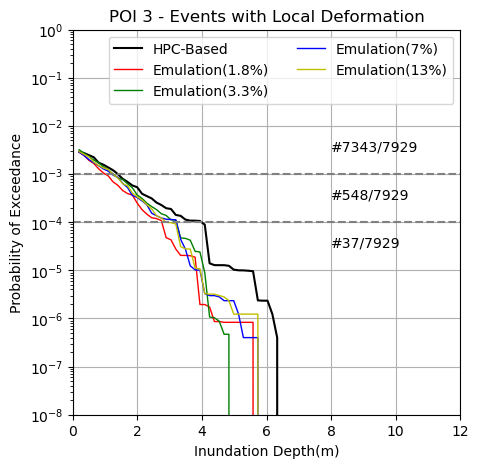

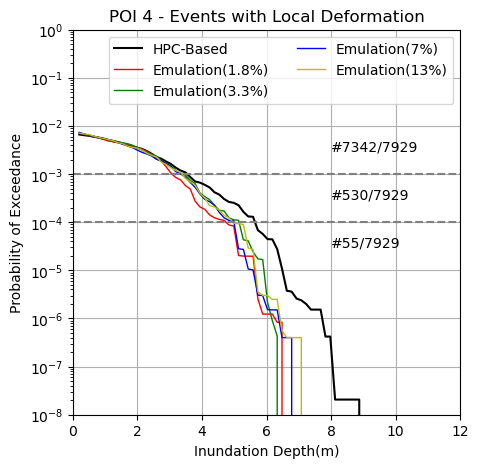

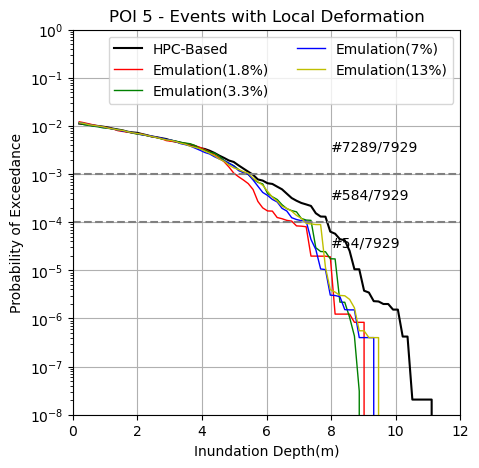

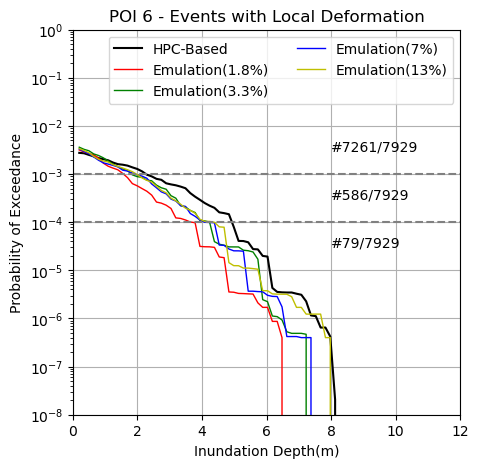

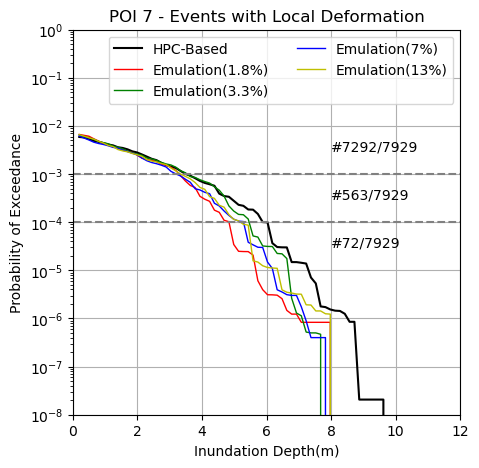

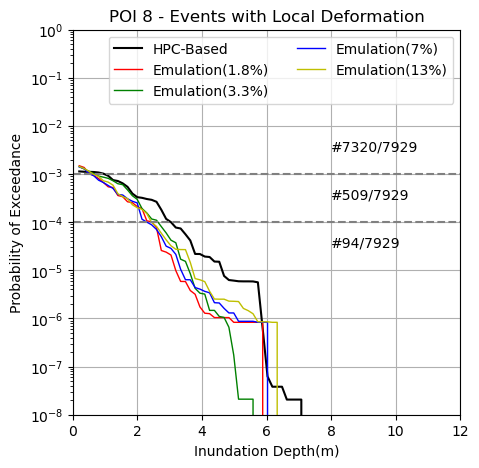

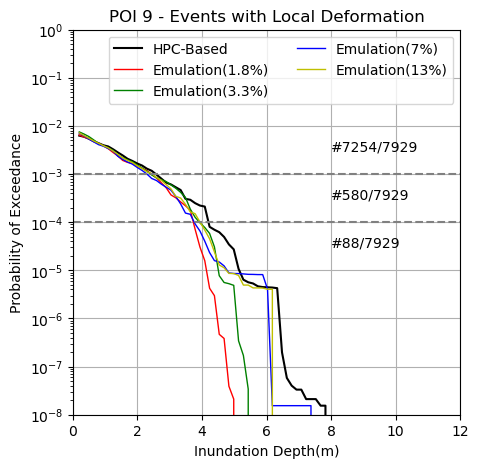

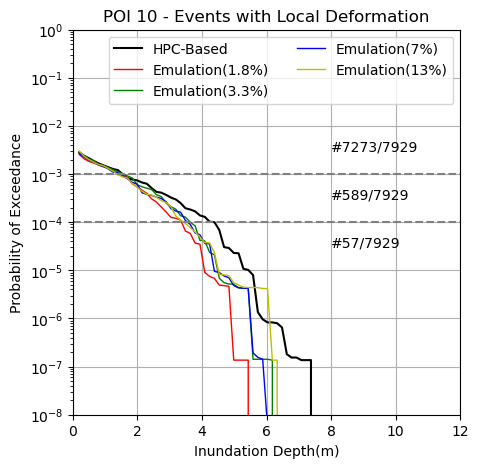

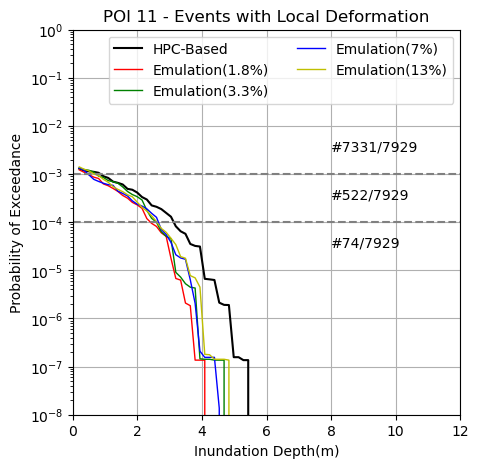

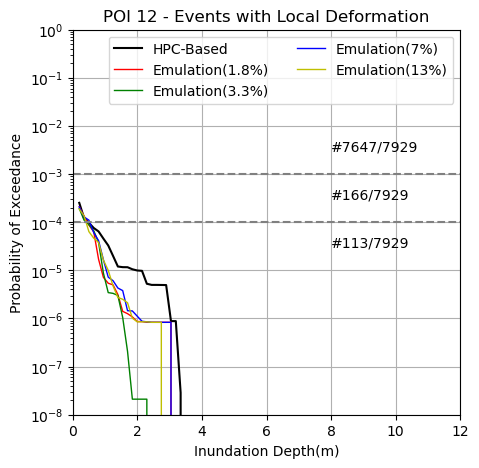

In [4]:
eve_dep_0 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_combined.csv')
eve_dep_1 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[1]}_true_pred_er_combined.csv')
eve_dep_2 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[2]}_true_pred_er_combined.csv')
eve_dep_3 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[3]}_true_pred_er_combined.csv')

eve_dep_0 = eve_dep_0[eve_def]
eve_dep_1 = eve_dep_1[eve_def]
eve_dep_2 = eve_dep_2[eve_def]
eve_dep_3 = eve_dep_3[eve_def]

#set depth thresholds
# thresholds_depth = [0.2,0.5,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
thresholds_depth = np.linspace(0.2, 15, num=100)
t= [1e-3,1e-4,1e-6]
def exceedance_count(true, thresholds_depth, lambda_exc_true, t = [1e-4,1e-6,1e-8]):
    ncount = []
    for i in range(len(t)):
        depth_idx = np.where(lambda_exc_true < t[i])[0]
        n = true[true > thresholds_depth[depth_idx[0]]].shape[0]
        ncount.append(n)
    ncount[1] = ncount[1] - ncount[2]
    return ncount

#iterate over points
for select_pt in range(1, 13):
    select_pt = str(select_pt)
    #true and predicted values
    true = eve_dep_0['T'+select_pt].values
    pred_0 = eve_dep_0['P'+select_pt].values
    pred_1 = eve_dep_1['P'+select_pt].values
    pred_2 = eve_dep_2['P'+select_pt].values
    pred_3 = eve_dep_3['P'+select_pt].values

    #compute exceedance curve for true
    lambda_exc_true = single_exceedance_rate(thresholds_depth, true, rate)
    lambda_exc_pred_0 = single_exceedance_rate(thresholds_depth, pred_0, rate)
    lambda_exc_pred_1 = single_exceedance_rate(thresholds_depth, pred_1, rate)
    lambda_exc_pred_2 = single_exceedance_rate(thresholds_depth, pred_2, rate)
    lambda_exc_pred_3 = single_exceedance_rate(thresholds_depth, pred_3, rate)

    #plot exceedance curve
    plt.figure(figsize=(5, 5))
    plt.plot(thresholds_depth,lambda_exc_true, label='HPC-Based', color='k',linewidth=1.5)
    plt.plot(thresholds_depth,lambda_exc_pred_0, label='Emulation(1.8%)', color='r',linewidth=1)
    plt.plot(thresholds_depth,lambda_exc_pred_1, label='Emulation(3.3%)', color='g',linewidth=1)
    plt.plot(thresholds_depth,lambda_exc_pred_2, label='Emulation(7%)', color='b',linewidth=1)
    plt.plot(thresholds_depth,lambda_exc_pred_3, label='Emulation(13%)', color='y',linewidth=1)
    #draw line exceed threshold probability of 1e-4, 1e-6, 1e-8
    plt.axhline(y=t[0], color='grey', linestyle='--')
    plt.axhline(y=t[1], color='grey', linestyle='--')

    
    #get nevents exceeding threshold probability of 1e-4, 1e-6, 1e-8 depths
    ncount = exceedance_count(true, thresholds_depth, lambda_exc_true,t)
    plt.text(8, 3*(1e-3), '#'+str(eve_dep_0.shape[0]-sum(ncount))+'/'+str(eve_dep_0.shape[0]), color='k')
    plt.text(8, 3*(1e-4), '#'+str(ncount[0])+'/'+str(eve_dep_0.shape[0]), color='k')
    plt.text(8, 3*(1e-5), '#'+str(ncount[1])+'/'+str(eve_dep_0.shape[0]), color='k')

    plt.xlabel('Inundation Depth(m)')
    plt.ylabel('Probability of Exceedance')
    plt.yscale('log')
    plt.grid(True)
    plt.ylim(1e-8, 1)
    plt.xlim(0, 12)
    plt.legend(ncol=2)
    plt.title(f'POI {select_pt} - Events with Local Deformation')
    plt.savefig(f'{MLDir}/risk/plots/hazard_compare/exceedance_{select_pt}_def.png')
    plt.show()


Haz Curve for no deformation events

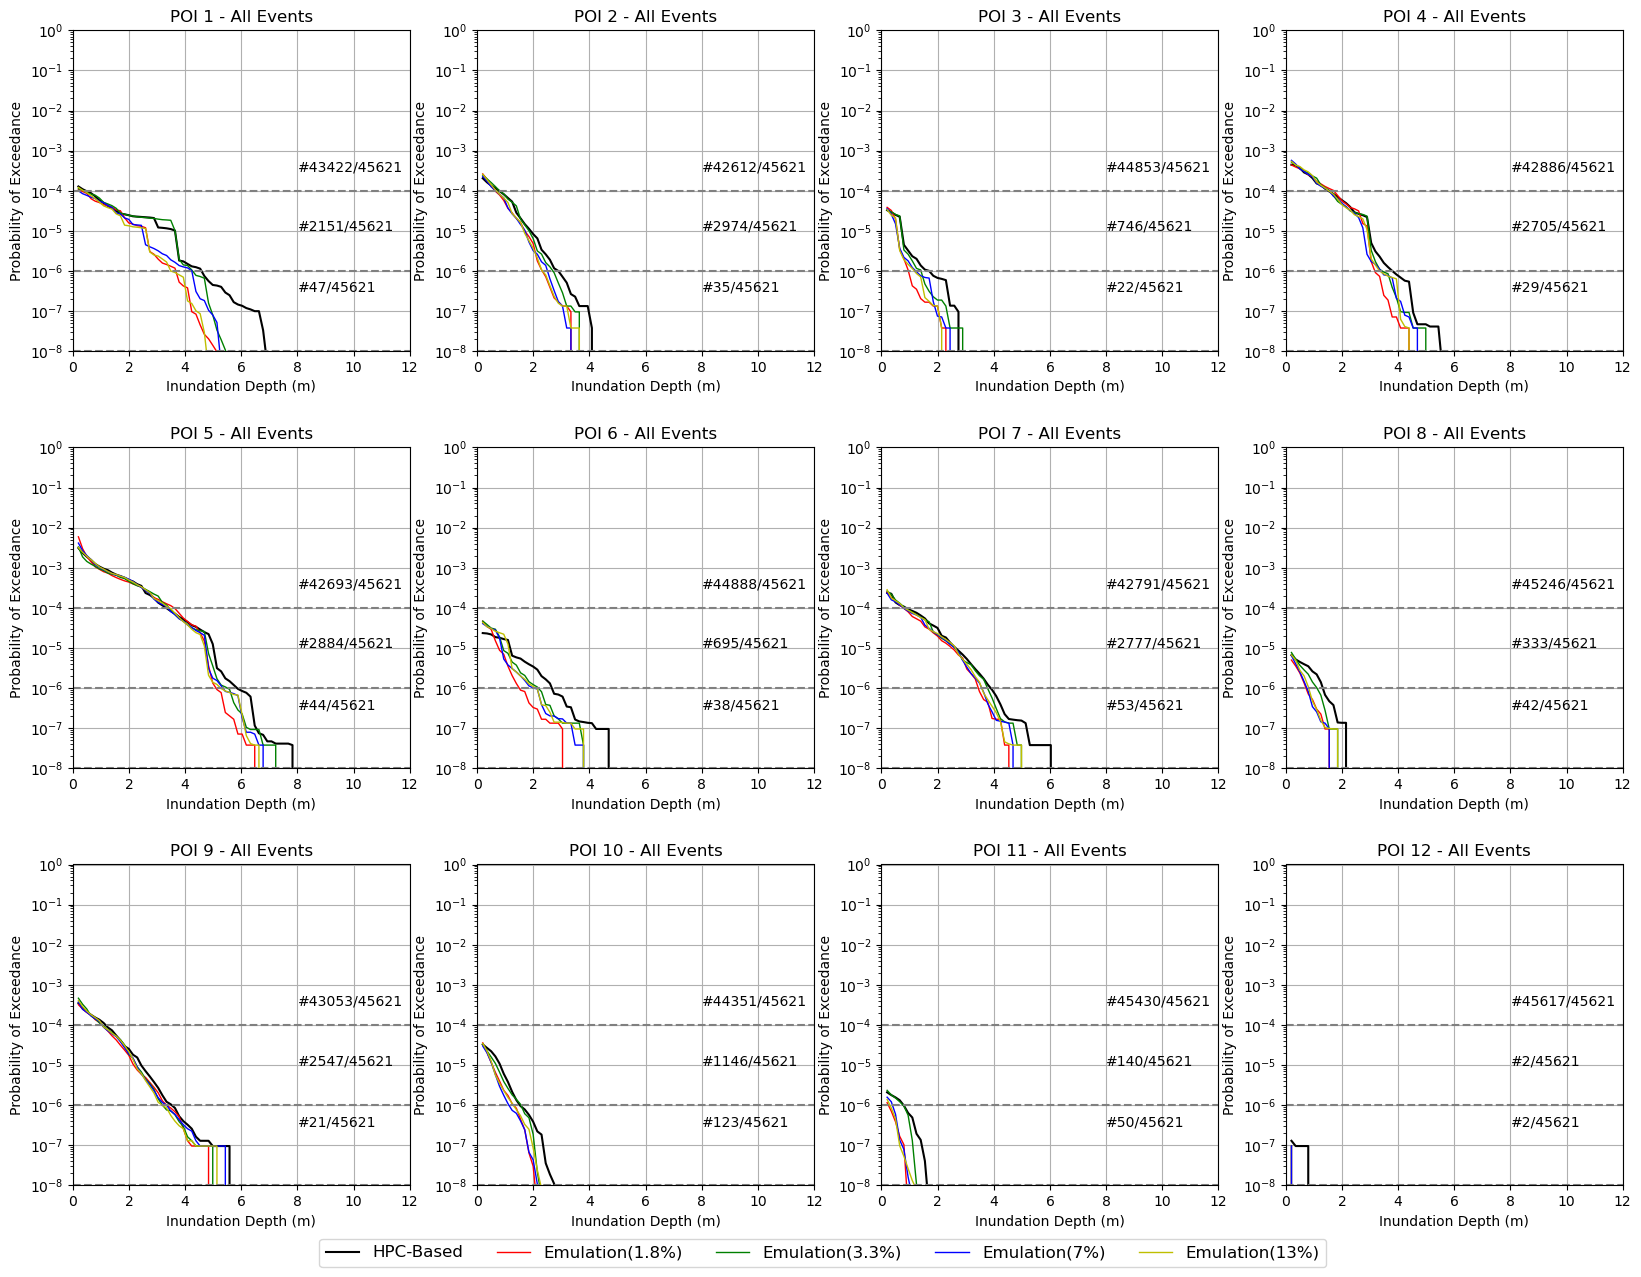

In [39]:
eve_dep_0 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_combined.csv')
eve_dep_1 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[1]}_true_pred_er_combined.csv')
eve_dep_2 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[2]}_true_pred_er_combined.csv')
eve_dep_3 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[3]}_true_pred_er_combined.csv')

eve_dep_0 = eve_dep_0[eve_nodef]
eve_dep_1 = eve_dep_1[eve_nodef]
eve_dep_2 = eve_dep_2[eve_nodef]
eve_dep_3 = eve_dep_3[eve_nodef]

#set depth thresholds
# thresholds_depth = [0.2,0.5,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
thresholds_depth = np.linspace(0.2, 15, num=100)
t = [1e-4,1e-6,1e-8]
def exceedance_count(true, thresholds_depth, lambda_exc_true, t = [1e-4,1e-6,1e-8]):
    ncount = []
    for i in range(len(t)):
        depth_idx = np.where(lambda_exc_true < t[i])[0]
        n = true[true > thresholds_depth[depth_idx[0]]].shape[0]
        ncount.append(n)
    ncount[1] = ncount[1] - ncount[2]
    return ncount

# Create subplots for all 12 sites
# Initialize a figure with 12 subplots (3 rows, 4 columns)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.subplots_adjust(hspace=0.3, wspace=0.2)  # Adjust space between subplots

# Iterate over points
for idx, select_pt in enumerate(range(1, 13)):  # Loop through POIs 1 to 12
    select_pt = str(select_pt)
    
    # True and predicted values
    true = eve_dep_0['T' + select_pt].values
    pred_0 = eve_dep_0['P' + select_pt].values
    pred_1 = eve_dep_1['P' + select_pt].values
    pred_2 = eve_dep_2['P' + select_pt].values
    pred_3 = eve_dep_3['P' + select_pt].values

    # Compute exceedance curves
    lambda_exc_true = single_exceedance_rate(thresholds_depth, true, rate)
    lambda_exc_pred_0 = single_exceedance_rate(thresholds_depth, pred_0, rate)
    lambda_exc_pred_1 = single_exceedance_rate(thresholds_depth, pred_1, rate)
    lambda_exc_pred_2 = single_exceedance_rate(thresholds_depth, pred_2, rate)
    lambda_exc_pred_3 = single_exceedance_rate(thresholds_depth, pred_3, rate)

    # Get subplot position
    row, col = divmod(idx, 4)
    ax = axes[row, col]
    
    # Plot exceedance curves
    ax.plot(thresholds_depth, lambda_exc_true, label='HPC-Based', color='k', linewidth=1.5)
    ax.plot(thresholds_depth, lambda_exc_pred_0, label='Emulation(1.8%)', color='r', linewidth=1)
    ax.plot(thresholds_depth, lambda_exc_pred_1, label='Emulation(3.3%)', color='g', linewidth=1)
    ax.plot(thresholds_depth, lambda_exc_pred_2, label='Emulation(7%)', color='b', linewidth=1)
    ax.plot(thresholds_depth, lambda_exc_pred_3, label='Emulation(13%)', color='y', linewidth=1)
    
    # Add horizontal lines for threshold probabilities
    for thresh in t:
        ax.axhline(y=thresh, color='grey', linestyle='--')
    
    # Add number of events exceeding thresholds
    ncount = exceedance_count(true, thresholds_depth, lambda_exc_true, t)
    ax.text(8, 3 * (1e-4), f'#{eve_dep_0.shape[0] - sum(ncount)}/{eve_dep_0.shape[0]}', color='k')
    ax.text(8, 1e-5, f'#{ncount[0]}/{eve_dep_0.shape[0]}', color='k')
    ax.text(8, 3 * (1e-7), f'#{ncount[1]}/{eve_dep_0.shape[0]}', color='k')
    
    # Set subplot title and axis labels
    ax.set_title(f'POI {select_pt} - All Events')
    ax.set_xlabel('Inundation Depth (m)')
    ax.set_ylabel('Probability of Exceedance')
    ax.set_yscale('log')
    ax.grid(True)
    ax.set_xlim(0, 12)
    ax.set_ylim(1e-8, 1)
    
# Adjust the legend position
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center',  # Position the legend below the subplots
    ncol=5,              # Number of columns in the legend
    fontsize=12,
    bbox_to_anchor=(0.5, 0.05),  # Move legend closer to the subplots
)

# Save and display the figure
plt.savefig(f'{MLDir}/risk/plots/hazard_compare/exceedance_all_nodef.png')
plt.show()

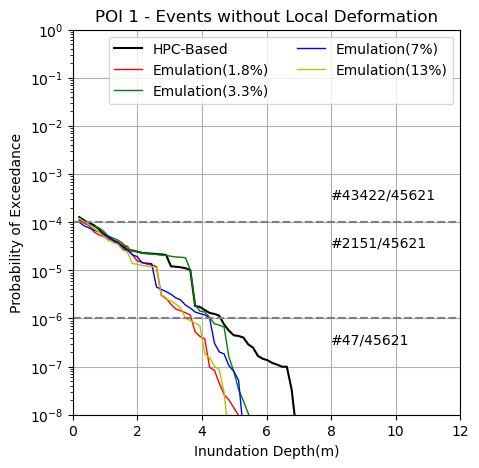

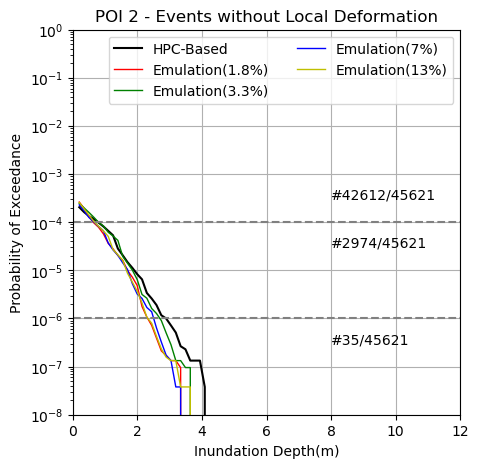

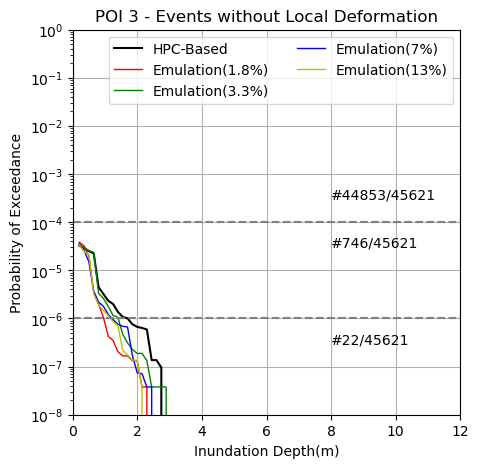

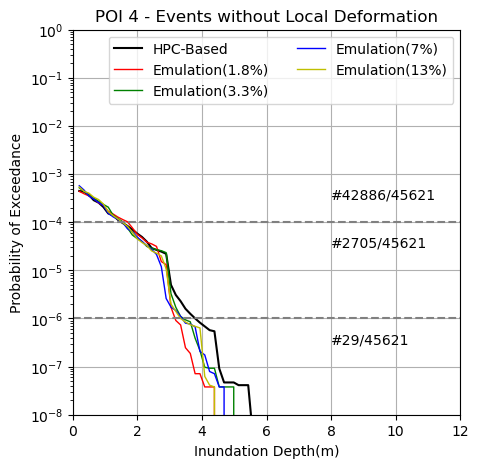

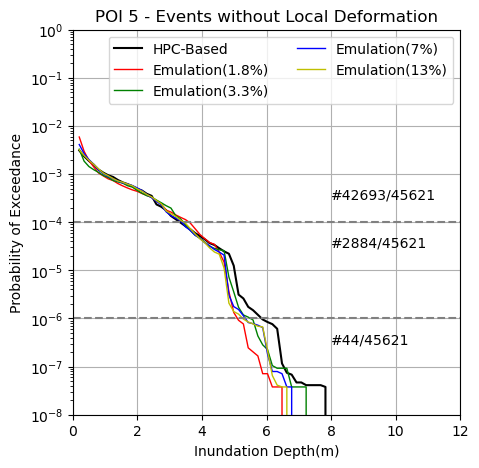

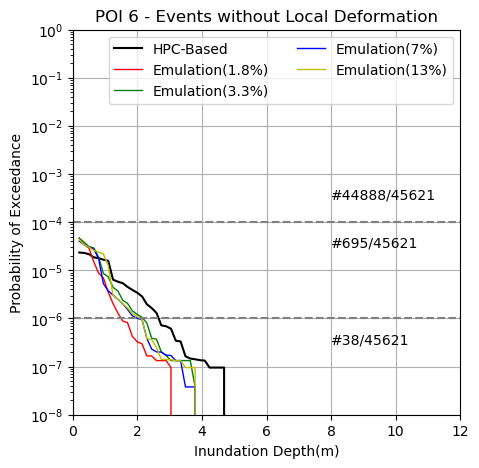

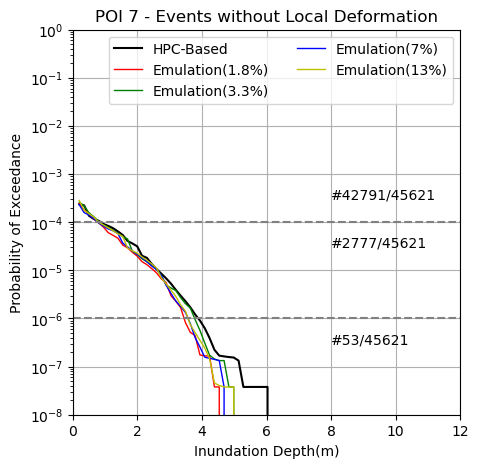

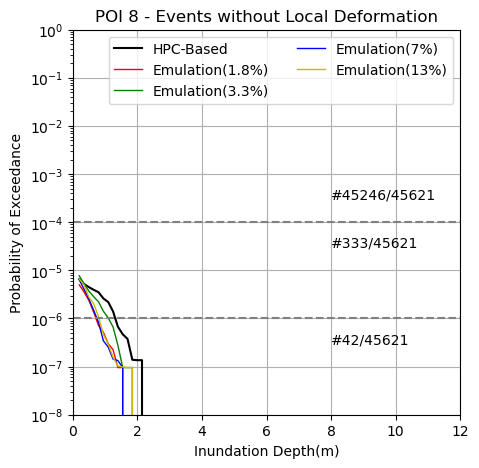

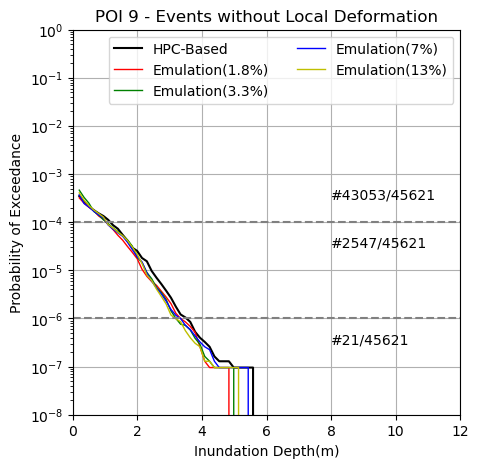

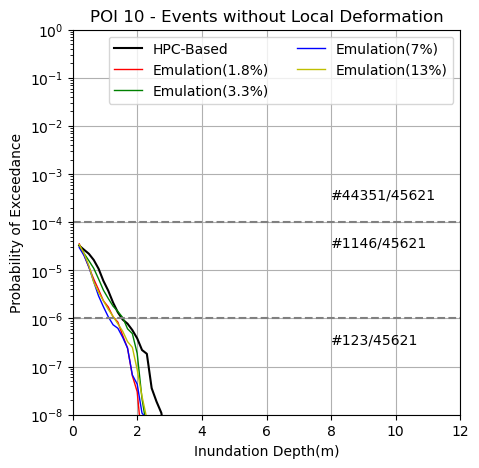

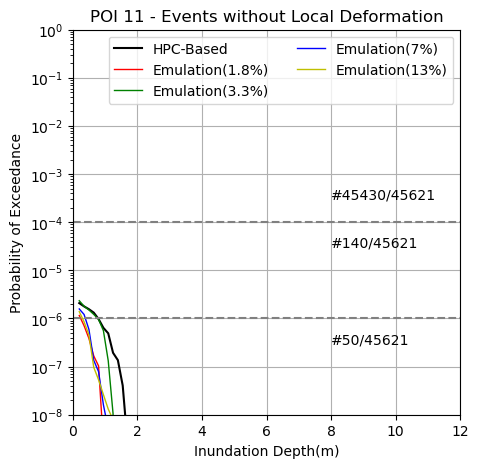

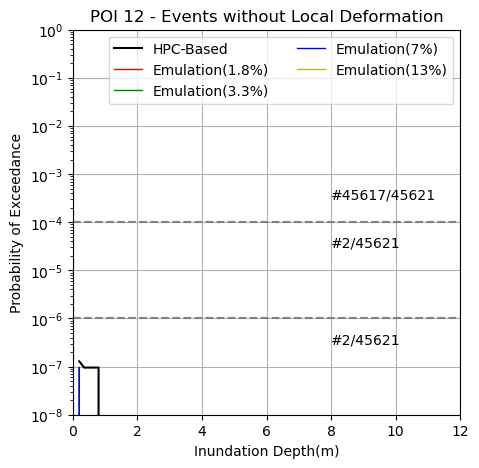

In [5]:
eve_dep_0 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_combined.csv')
eve_dep_1 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[1]}_true_pred_er_combined.csv')
eve_dep_2 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[2]}_true_pred_er_combined.csv')
eve_dep_3 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[3]}_true_pred_er_combined.csv')

eve_dep_0 = eve_dep_0[eve_nodef]
eve_dep_1 = eve_dep_1[eve_nodef]
eve_dep_2 = eve_dep_2[eve_nodef]
eve_dep_3 = eve_dep_3[eve_nodef]

#set depth thresholds
# thresholds_depth = [0.2,0.5,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
thresholds_depth = np.linspace(0.2, 15, num=100)
t = [1e-4,1e-6,1e-8]
def exceedance_count(true, thresholds_depth, lambda_exc_true, t = [1e-4,1e-6,1e-8]):
    ncount = []
    for i in range(len(t)):
        depth_idx = np.where(lambda_exc_true < t[i])[0]
        n = true[true > thresholds_depth[depth_idx[0]]].shape[0]
        ncount.append(n)
    ncount[1] = ncount[1] - ncount[2]
    return ncount

#iterate over points
for select_pt in range(1, 13):
    select_pt = str(select_pt)
    #true and predicted values
    true = eve_dep_0['T'+select_pt].values
    pred_0 = eve_dep_0['P'+select_pt].values
    pred_1 = eve_dep_1['P'+select_pt].values
    pred_2 = eve_dep_2['P'+select_pt].values
    pred_3 = eve_dep_3['P'+select_pt].values

    #compute exceedance curve for true
    lambda_exc_true = single_exceedance_rate(thresholds_depth, true, rate)
    lambda_exc_pred_0 = single_exceedance_rate(thresholds_depth, pred_0, rate)
    lambda_exc_pred_1 = single_exceedance_rate(thresholds_depth, pred_1, rate)
    lambda_exc_pred_2 = single_exceedance_rate(thresholds_depth, pred_2, rate)
    lambda_exc_pred_3 = single_exceedance_rate(thresholds_depth, pred_3, rate)

    #plot exceedance curve
    plt.figure(figsize=(5, 5))
    plt.plot(thresholds_depth,lambda_exc_true, label='HPC-Based', color='k',linewidth=1.5)
    plt.plot(thresholds_depth,lambda_exc_pred_0, label='Emulation(1.8%)', color='r',linewidth=1)
    plt.plot(thresholds_depth,lambda_exc_pred_1, label='Emulation(3.3%)', color='g',linewidth=1)
    plt.plot(thresholds_depth,lambda_exc_pred_2, label='Emulation(7%)', color='b',linewidth=1)
    plt.plot(thresholds_depth,lambda_exc_pred_3, label='Emulation(13%)', color='y',linewidth=1)
    #draw line exceed threshold probability of 1e-4, 1e-6, 1e-8
    plt.axhline(y=t[0], color='grey', linestyle='--')
    plt.axhline(y=t[1], color='grey', linestyle='--')

    
    #get nevents exceeding threshold probability of 1e-4, 1e-6, 1e-8 depths
    ncount = exceedance_count(true, thresholds_depth, lambda_exc_true,t)
    plt.text(8, 3*(1e-4), '#'+str(eve_dep_0.shape[0]-sum(ncount))+'/'+str(eve_dep_0.shape[0]), color='k')
    plt.text(8, 3*(1e-5), '#'+str(ncount[0])+'/'+str(eve_dep_0.shape[0]), color='k')
    plt.text(8, 3*(1e-7), '#'+str(ncount[1])+'/'+str(eve_dep_0.shape[0]), color='k')

    plt.xlabel('Inundation Depth(m)')
    plt.ylabel('Probability of Exceedance')
    plt.yscale('log')
    plt.grid(True)
    plt.ylim(1e-8, 1)
    plt.xlim(0, 12)
    plt.legend(ncol=2)
    plt.title(f'POI {select_pt} - Events without Local Deformation')
    plt.savefig(f'{MLDir}/risk/plots/hazard_compare/exceedance_{select_pt}_nodef.png')
    plt.show()


Relative Error in Haz Curves

/tmp/ipykernel_38640/1165573501.py:28: RuntimeWarning: invalid value encountered in divide
  rel_errors = [(rp_depth_true - rp_depth_pred) / rp_depth_true for rp_depth_pred in rp_depth_preds]
/tmp/ipykernel_38640/1165573501.py:28: RuntimeWarning: divide by zero encountered in divide
  rel_errors = [(rp_depth_true - rp_depth_pred) / rp_depth_true for rp_depth_pred in rp_depth_preds]


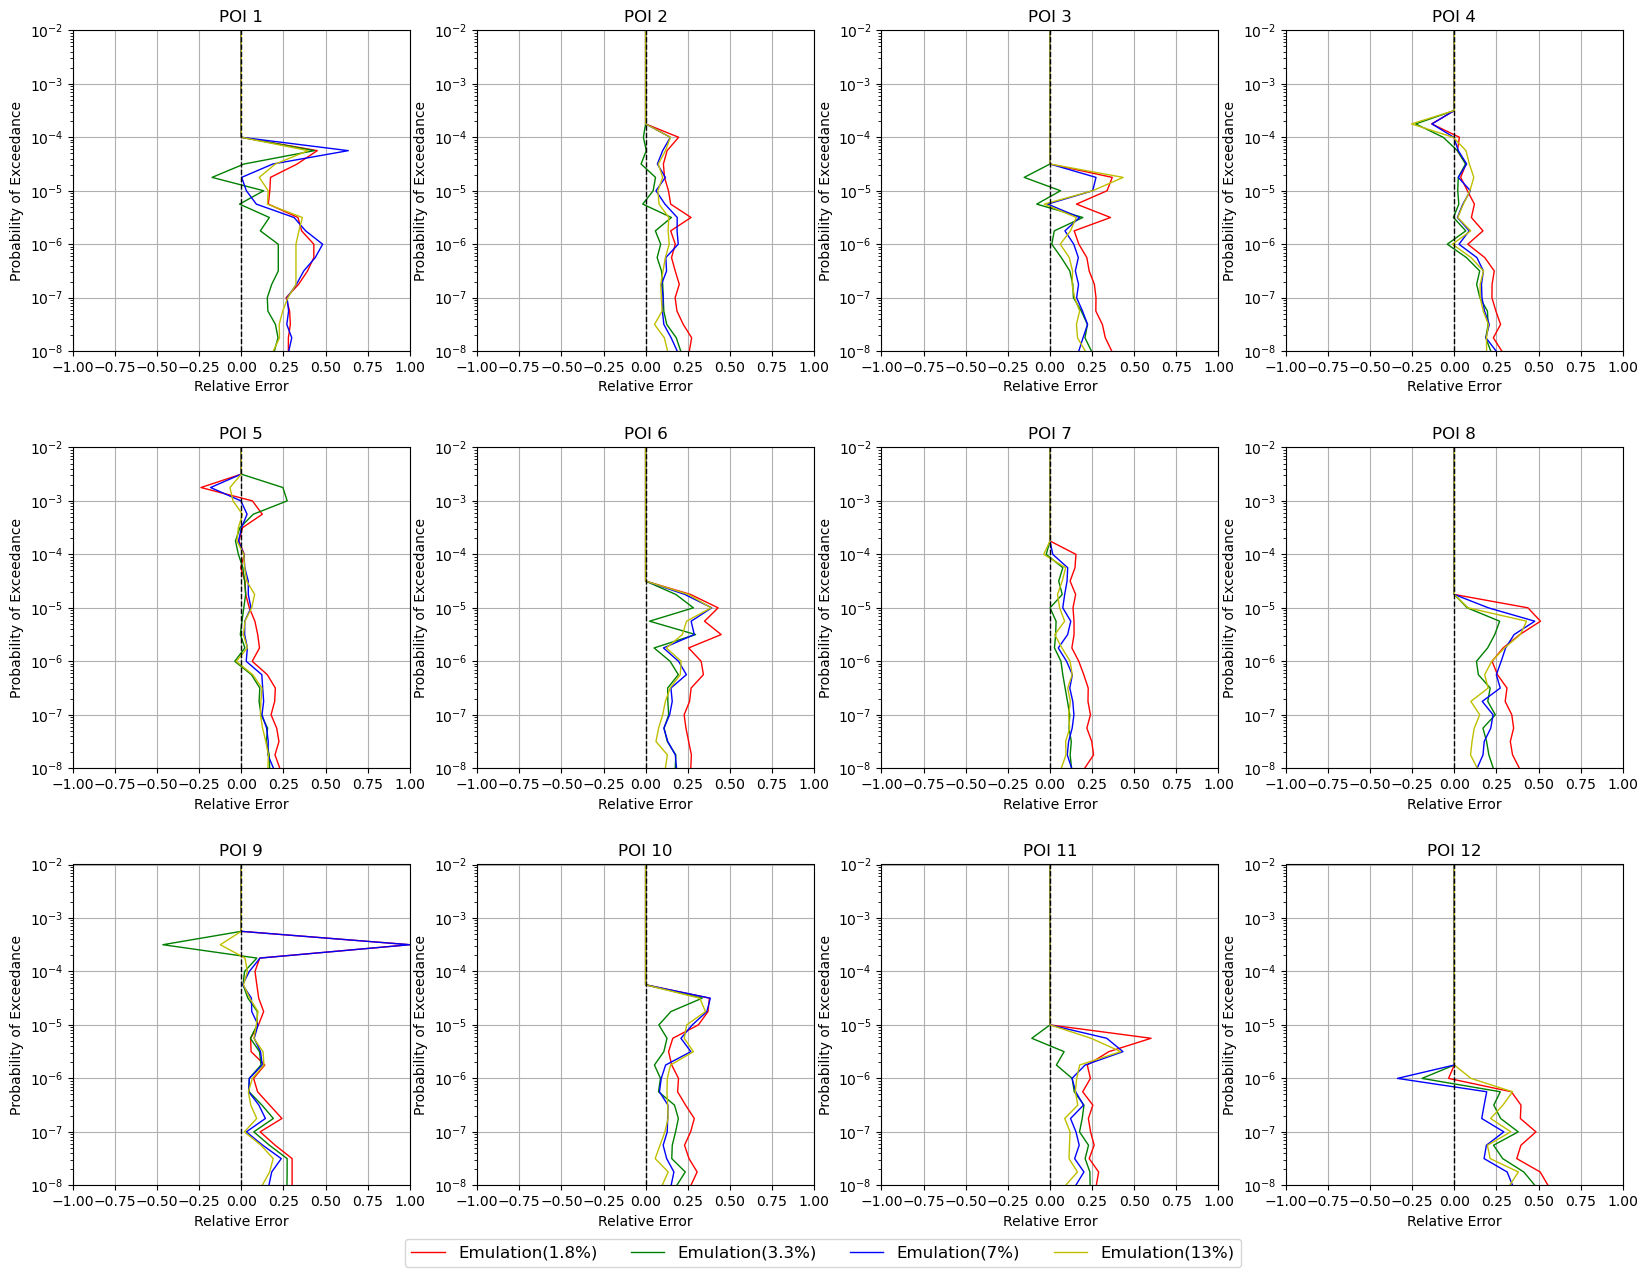

In [32]:
# Read data for all event predictions
eve_dep = [
    pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[i]}_true_pred_er_combined.csv')
    for i in range(4)
]

# Set depth thresholds
thresholds_rate = np.logspace(-8, 0, num=33, base=10.0)

# Create subplots for all 12 POIs
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.subplots_adjust(hspace=0.3, wspace=0.2)  # Adjust space between subplots
axes = axes.flatten()

for select_pt in range(1, 13):
    ax = axes[select_pt - 1]  # Get the appropriate subplot axis
    select_pt_str = str(select_pt)
    
    # Extract true and predicted values
    true = eve_dep[0][f'T{select_pt_str}'].values
    preds = [data[f'P{select_pt_str}'].values for data in eve_dep]

    # Compute exceedance depths
    rp_depth_true = single_exceedance_depth(thresholds_rate, true, rate)
    rp_depth_preds = [single_exceedance_depth(thresholds_rate, pred, rate) for pred in preds]

    # Compute relative errors
    rel_errors = [(rp_depth_true - rp_depth_pred) / rp_depth_true for rp_depth_pred in rp_depth_preds]

    # Handle NaN and threshold conditions for relative errors
    for rel_error in rel_errors:
        rel_error[np.isnan(rel_error)] = 0
        rel_error[np.where(rp_depth_true < 0.2)[0]] = 0

    # Plot relative errors
    colors = ['r', 'g', 'b', 'y']
    labels = ['Emulation(1.8%)', 'Emulation(3.3%)', 'Emulation(7%)', 'Emulation(13%)']
    for rel_error, color, label in zip(rel_errors, colors, labels):
        ax.plot(rel_error, thresholds_rate, label=label, color=color, linewidth=1)
    
    # Add a vertical line at 0
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    
    # Customize the subplot
    ax.set_title(f'POI {select_pt}')
    ax.grid(True)
    ax.set_xscale('linear')
    ax.set_yscale('log')
    ax.set_xlim(-1, 1)
    ax.set_ylim(1e-8, 1e-2)
    ax.set_xlabel('Relative Error')
    ax.set_ylabel('Probability of Exceedance')

# Adjust the legend position
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center',  # Position the legend below the subplots
    ncol=4,              # Number of columns in the legend
    fontsize=12,
    bbox_to_anchor=(0.5, +0.05),  # Move legend closer to the subplots
)

# Adjust layout and save the figure
plt.savefig(f'{MLDir}/risk/plots/hazard_compare/rel_err_all.png')
plt.show()


/tmp/ipykernel_38640/1161090168.py:36: RuntimeWarning: invalid value encountered in divide
  rel_error_0 = (rp_depth_true - rp_depth_pred_0)/rp_depth_true
/tmp/ipykernel_38640/1161090168.py:37: RuntimeWarning: invalid value encountered in divide
  rel_error_1 = (rp_depth_true - rp_depth_pred_1)/rp_depth_true
/tmp/ipykernel_38640/1161090168.py:38: RuntimeWarning: invalid value encountered in divide
  rel_error_2 = (rp_depth_true - rp_depth_pred_2)/rp_depth_true
/tmp/ipykernel_38640/1161090168.py:39: RuntimeWarning: divide by zero encountered in divide
  rel_error_3 =(rp_depth_true - rp_depth_pred_3)/rp_depth_true
/tmp/ipykernel_38640/1161090168.py:39: RuntimeWarning: invalid value encountered in divide
  rel_error_3 =(rp_depth_true - rp_depth_pred_3)/rp_depth_true


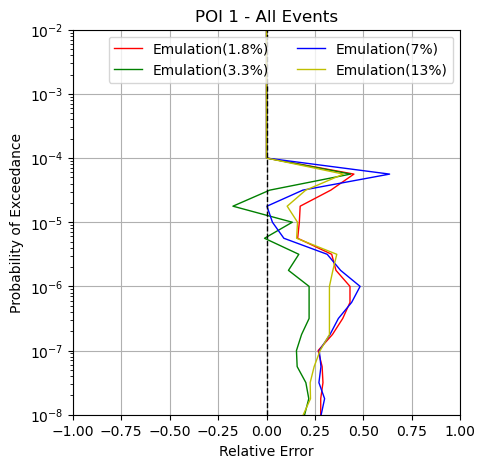

/tmp/ipykernel_38640/1161090168.py:36: RuntimeWarning: divide by zero encountered in divide
  rel_error_0 = (rp_depth_true - rp_depth_pred_0)/rp_depth_true
/tmp/ipykernel_38640/1161090168.py:37: RuntimeWarning: divide by zero encountered in divide
  rel_error_1 = (rp_depth_true - rp_depth_pred_1)/rp_depth_true
/tmp/ipykernel_38640/1161090168.py:38: RuntimeWarning: divide by zero encountered in divide
  rel_error_2 = (rp_depth_true - rp_depth_pred_2)/rp_depth_true


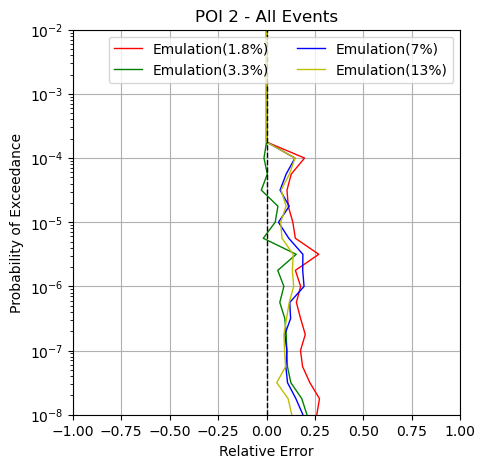

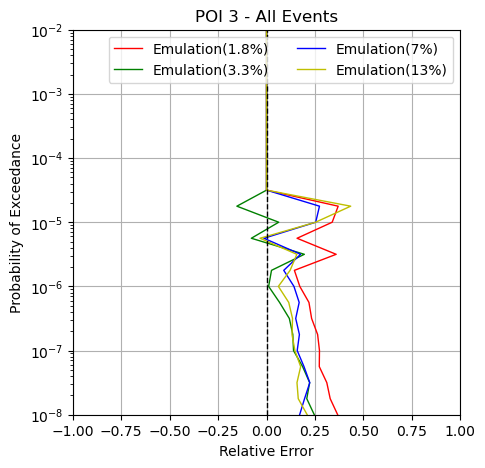

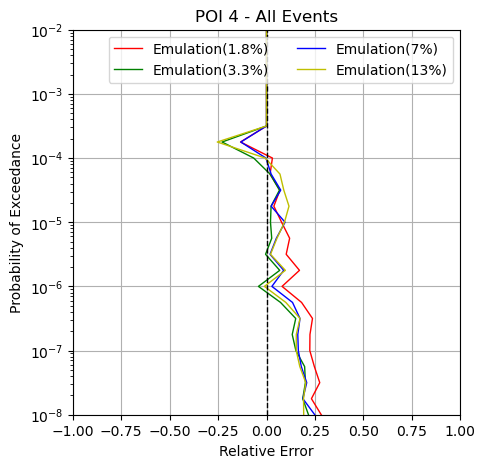

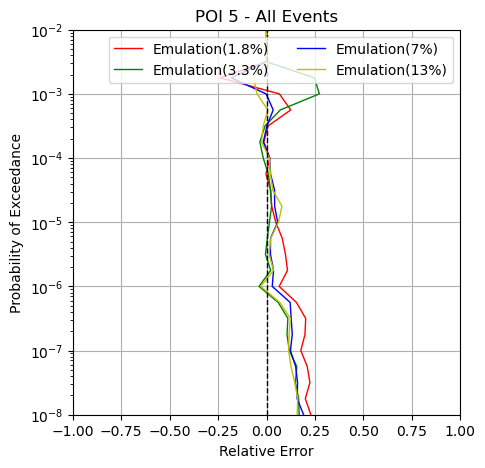

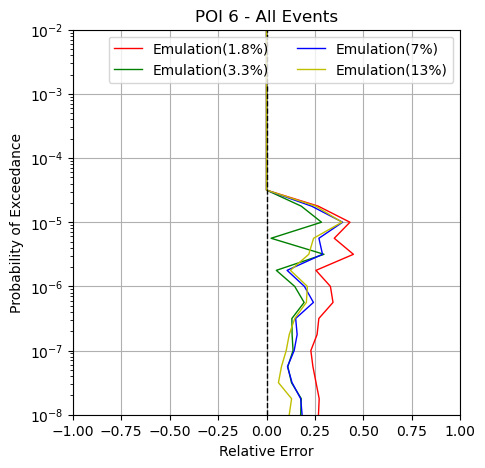

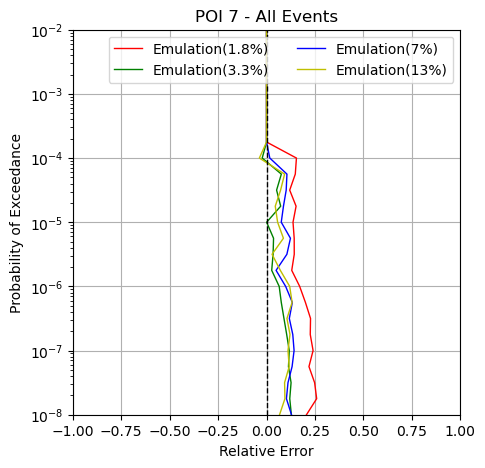

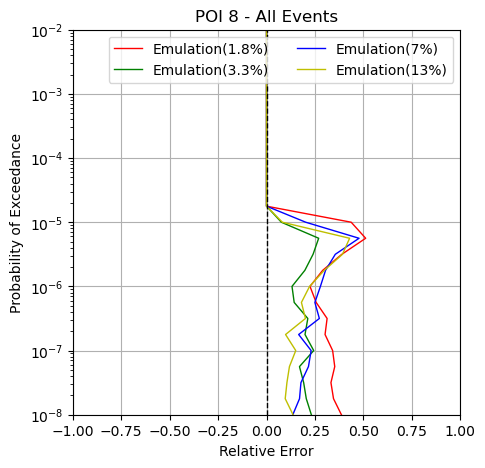

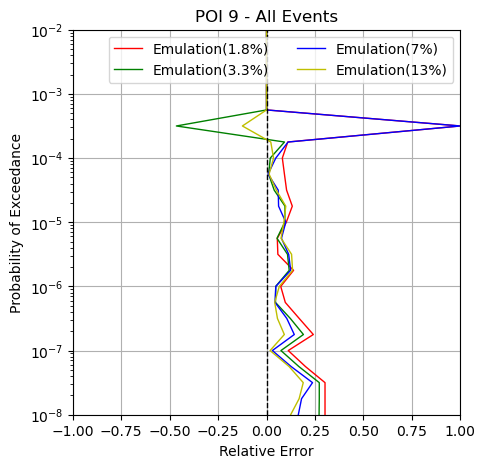

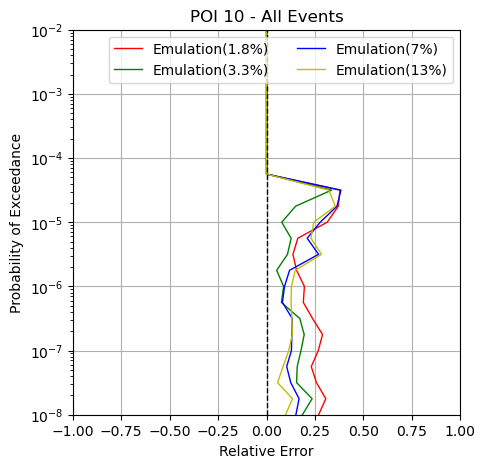

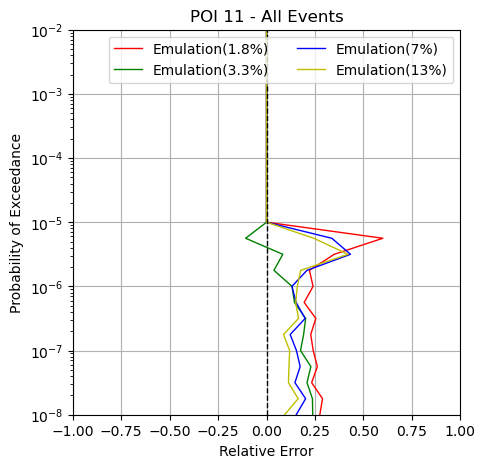

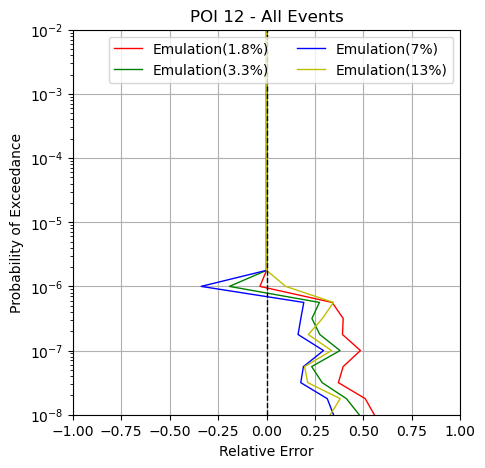

In [ ]:
eve_dep_0 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_combined.csv')
eve_dep_1 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[1]}_true_pred_er_combined.csv')
eve_dep_2 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[2]}_true_pred_er_combined.csv')
eve_dep_3 = pd.read_csv(f'{MLDir}/model/{reg}/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[3]}_true_pred_er_combined.csv')

#set depth thresholds
# thresholds_rate = [1e-8,2e-8,4e-8,8e-8,
#                     1e-7,2e-7,4e-7,8e-7,
#                         1e-6,2e-6,4e-6,8e-6,
#                             1e-5,2e-5,4e-5,8e-5,
#                                 1e-4,2e-4,4e-4,8e-4,
#                                     1e-3,2e-3,4e-3,8e-3,
#                                         1e-2,2e-2,4e-2,8e-2,
#                                             1e-1,2e-1,4e-1,8e-1,]

thresholds_rate = np.logspace(-8, 0, num=33, base=10.0)

#iterate over points
for select_pt in range(1, 13):
    select_pt = str(select_pt)
    #true and predicted values
    true = eve_dep_0['T'+select_pt].values
    pred_0 = eve_dep_0['P'+select_pt].values
    pred_1 = eve_dep_1['P'+select_pt].values
    pred_2 = eve_dep_2['P'+select_pt].values
    pred_3 = eve_dep_3['P'+select_pt].values

    #compute exceedance curve for true
    rp_depth_true = single_exceedance_depth(thresholds_rate, true, rate)
    rp_depth_pred_0 = single_exceedance_depth(thresholds_rate, pred_0, rate)
    rp_depth_pred_1 = single_exceedance_depth(thresholds_rate, pred_1, rate)
    rp_depth_pred_2 = single_exceedance_depth(thresholds_rate, pred_2, rate)
    rp_depth_pred_3 = single_exceedance_depth(thresholds_rate, pred_3, rate)

    #compute relative error for each threshold of return period between predictions and true
    rel_error_0 = (rp_depth_true - rp_depth_pred_0)/rp_depth_true
    rel_error_1 = (rp_depth_true - rp_depth_pred_1)/rp_depth_true
    rel_error_2 = (rp_depth_true - rp_depth_pred_2)/rp_depth_true
    rel_error_3 =(rp_depth_true - rp_depth_pred_3)/rp_depth_true

    #if rp_depth_true is 0, set relative error to 0
    rel_error_0[np.isnan(rel_error_0)] = 0
    rel_error_1[np.isnan(rel_error_1)] = 0
    rel_error_2[np.isnan(rel_error_2)] = 0
    rel_error_3[np.isnan(rel_error_3)] = 0

    #set all relative errors for depths less than 20 cm to 0
    rel_error_0[np.where(rp_depth_true < 0.2)[0]] = 0
    rel_error_1[np.where(rp_depth_true < 0.2)[0]] = 0
    rel_error_2[np.where(rp_depth_true < 0.2)[0]] = 0
    rel_error_3[np.where(rp_depth_true < 0.2)[0]] = 0

    #plot exceedance curve
    plt.figure(figsize=(5, 5))
    plt.plot(rel_error_0,thresholds_rate, label='Emulation(1.8%)', color='r',linewidth=1)
    plt.plot(rel_error_1,thresholds_rate, label='Emulation(3.3%)', color='g',linewidth=1)
    plt.plot(rel_error_2,thresholds_rate, label='Emulation(7%)', color='b',linewidth=1)
    plt.plot(rel_error_3,thresholds_rate, label='Emulation(13%)', color='y',linewidth=1)
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.ylabel('Probability of Exceedance')
    plt.xlabel('Relative Error')
    plt.yscale('log')
    plt.grid(True)
    plt.xlim(-1, 1)
    plt.ylim(1e-8,1e-2)
    plt.legend(ncol=2)
    plt.title(f'POI {select_pt} - All Events')
    plt.savefig(f'{MLDir}/risk/plots/hazard_compare/rel_err_{select_pt}_all.png')
    plt.show()
